# Battery Energy Flow Forecast Notebook

Build a daily 24h (UTC, 15-minute) dispatch schedule for PV, battery, and grid.
The notebook is designed to be easy to change: edit the parameter cell, then rerun from top.

## Notebook Roadmap

1. Define editable battery and market parameters.
2. Define input contract and load/create input data.
3. Validate and normalize input data.
4. Run rule-based dispatch (transparent baseline).
5. Run LP optimization to minimize daily cost.
6. Export the final dispatch schedule.

In [52]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import ListedColormap

from ipywidgets import interact, SelectionSlider
from scipy.optimize import linprog

pd.set_option("display.max_columns", 200) # Allow displaying all columns in DataFrames without truncation.
pd.set_option("display.width", 200) # Set display width to prevent line breaks in DataFrame display. Adjust as needed for your screen size.


## Helper Functions

In [53]:
def plot_step_dataframe(
    df: pd.DataFrame,
    params: dict | None = None,
    title: str = "Dispatch / Forecast Overview",
    timestamp_col: str = "utc_timestamp",
) -> None:
    """Auto-detects columns and renders: energy flows, SoC, and cost/price."""
    plot_df = df.copy()

    if timestamp_col in plot_df.columns:
        plot_df[timestamp_col] = pd.to_datetime(plot_df[timestamp_col], utc=True, errors="coerce")
        if plot_df[timestamp_col].isna().any():
            raise ValueError(f"Column '{timestamp_col}' contains invalid timestamps.")
        x_axis = (plot_df[timestamp_col] - plot_df[timestamp_col].iloc[0]).dt.total_seconds() / 3600.0
        x_label = "Hour of day (UTC)"
    else:
        x_axis = np.arange(len(plot_df))
        x_label = "Row index"

    fig, (ax_flow, ax_soc, ax_cost) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # --- Panel 1: Energy flows ---
    flow_specs = [
        ("household_load_kwh",  "Household load",  "#1f77b4", "plot"),
        ("pv_generation_kwh",   "PV generation",   "#f4a216", "plot"),
        ("grid_to_load_kwh",    "Grid to load",    "#d62728", "step"),
        ("battery_to_load_kwh", "Battery to load", "#2ca02c", "step"),
        ("pv_to_battery_kwh",   "PV to battery",   "#17becf", "step"),
        ("grid_to_battery_kwh", "Grid to battery", "#9467bd", "step"),
        ("export_to_grid_kwh",  "Export to grid",  "#8c564b", "step"),
    ]
    has_flows = False
    for col, label, color, mode in flow_specs:
        if col not in plot_df.columns:
            continue
        if mode == "step":
            ax_flow.step(x_axis, plot_df[col], where="post", linewidth=1.3, color=color, label=label)
        else:
            ax_flow.plot(x_axis, plot_df[col], linewidth=1.8, color=color, label=label)
        has_flows = True
    if not has_flows:
        ax_flow.text(0.5, 0.5, "No flow columns found.", ha="center", va="center", transform=ax_flow.transAxes)
    ax_flow.set_ylabel("kWh per 15 min")
    if has_flows:
        ax_flow.legend(loc="upper right", fontsize=8, ncol=2)

    # --- Panel 2: State of Charge ---
    soc_col = "soc_kwh" if "soc_kwh" in plot_df.columns else ("soc_percent" if "soc_percent" in plot_df.columns else None)
    if soc_col:
        soc_unit = "kWh" if soc_col == "soc_kwh" else "%"
        ax_soc.plot(x_axis, plot_df[soc_col], color="#8c564b", linewidth=2.0, label=f"SoC ({soc_unit})")
        if soc_col == "soc_kwh" and params and "soc_min_kwh" in params and "soc_max_kwh" in params:
            ax_soc.axhline(params["soc_min_kwh"], color="#888", ls="--", lw=1.0, label="SoC min/max")
            ax_soc.axhline(params["soc_max_kwh"], color="#888", ls="--", lw=1.0)
        ax_soc.set_ylabel(f"SoC ({soc_unit})")
        ax_soc.legend(loc="upper right", fontsize=8)
    else:
        ax_soc.text(0.5, 0.5, "No SoC columns found.", ha="center", va="center", transform=ax_soc.transAxes)
        ax_soc.set_ylabel("SoC")

    # --- Panel 3: Cost & price ---
    has_cost = False
    if "cumulative_cost_cent" in plot_df.columns:
        ax_cost.plot(x_axis, plot_df["cumulative_cost_cent"], color="#9467bd", linewidth=2.0, label="Cumulative cost (cent)")
        has_cost = True
    elif "interval_cost_cent" in plot_df.columns:
        ax_cost.plot(x_axis, plot_df["interval_cost_cent"].cumsum(), color="#9467bd", linewidth=2.0, label="Cumulative cost (cent)")
        has_cost = True

    price_col = next((c for c in ["predicted_energy_price_buy_cent_kwh", "energy_price_buy_cent_kwh"] if c in plot_df.columns), None)
    sell_price = float(params["default_sell_price_cent_kwh"]) if params and "default_sell_price_cent_kwh" in params else None

    if price_col or sell_price is not None:
        ax_price = ax_cost.twinx()
        if price_col:
            ax_price.plot(x_axis, plot_df[price_col], color="#ff7f0e", lw=1.8, ls="--", label="Buy price (cent/kWh)")
        if sell_price is not None:
            ax_price.axhline(sell_price, color="#2ca02c", lw=1.5, ls=":", label="Sell price (cent/kWh)")
        ax_price.set_ylabel("Price (cent/kWh)")
        ax_price.legend(loc="upper right", fontsize=8)
        ax_price.grid(False)

    ax_cost.set_xlabel(x_label)
    ax_cost.set_ylabel("cent")
    if has_cost:
        ax_cost.legend(loc="upper left", fontsize=8)
    elif not price_col and sell_price is None:
        ax_cost.text(0.5, 0.5, "No cost columns found.", ha="center", va="center", transform=ax_cost.transAxes)

    # Shared grid formatting
    for ax in (ax_flow, ax_soc, ax_cost):
        ax.grid(True, linestyle="--", alpha=0.35, which="both")
        ax.xaxis.grid(True, linestyle="--", alpha=0.85, which="major")

    if timestamp_col in plot_df.columns:
        ax_cost.xaxis.set_major_locator(mticker.MultipleLocator(3))
        ax_cost.xaxis.set_minor_locator(mticker.MultipleLocator(1))

    fig.tight_layout()
    plt.show()


In [54]:
def plot_decision_heatmap(
    df: pd.DataFrame,
    title: str = "Active Decision Rules per Interval",
    timestamp_col: str = "utc_timestamp",
) -> None:
    """Binary heatmap showing which energy flow types are active per interval."""
    flow_specs = [
        ("pv_to_load",      "PV to load",      "#f4a216"),
        ("pv_to_battery",   "PV to battery",   "#17becf"),
        ("battery_to_load", "Battery to load", "#2ca02c"),
        ("grid_to_load",    "Grid to load",    "#d62728"),
        ("grid_to_battery", "Grid to battery", "#9467bd"),
        ("export_to_grid",  "Export to grid",  "#8c564b"),
    ]

    flow_types = [s[0] for s in flow_specs]
    flow_labels = [s[1] for s in flow_specs]
    flow_colors = [s[2] for s in flow_specs]

    matrix = np.array(
        [[ft in rule for rule in df["decision_rule"]] for ft in flow_types],
        dtype=float,
    )

    timestamps = pd.to_datetime(df[timestamp_col], utc=True)
    hours = ((timestamps - timestamps.iloc[0]).dt.total_seconds() / 3600.0).values
    x_edges = np.append(hours, hours[-1] + 0.25)

    fig, ax = plt.subplots(figsize=(14, 3))
    for i, color in enumerate(flow_colors):
        cmap = ListedColormap(["#f7f7f7", color])
        ax.pcolormesh(
            x_edges, [i, i + 1], matrix[i : i + 1],
            cmap=cmap, edgecolors="white", linewidth=0.5,
        )

    ax.set_yticks(np.arange(len(flow_types)) + 0.5)
    ax.set_yticklabels(flow_labels, fontsize=9)
    ax.set_xlabel("Hour of day (UTC)")
    ax.set_title(title, fontweight="bold")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(3))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
    fig.tight_layout()
    plt.show()


In [55]:
def plot_energy_flow_diagram(
    df: pd.DataFrame,
    interval: int,
    params: dict,
    timestamp_col: str = "utc_timestamp",
) -> None:
    """Energy flow diagram for a single dispatch interval with proportional arrows."""
    row = df.iloc[interval]
    ts = pd.to_datetime(row[timestamp_col])

    flows = {
        "pv_to_load":      float(row["pv_to_load_kwh"]),
        "pv_to_battery":   float(row["pv_to_battery_kwh"]),
        "battery_to_load": float(row["battery_to_load_kwh"]),
        "grid_to_load":    float(row["grid_to_load_kwh"]),
        "grid_to_battery": float(row["grid_to_battery_kwh"]),
        "export_to_grid":  float(row["export_to_grid_kwh"]),
    }

    pv_gen     = float(row["pv_generation_kwh"])
    load_dem   = float(row["household_load_kwh"])
    soc        = float(row["soc_kwh"])
    soc_pct    = soc / params["battery_capacity_kwh"] * 100
    buy_price  = float(row["energy_price_buy_cent_kwh"])
    sell_price = float(row["energy_price_sell_cent_kwh"])
    cost       = float(row["interval_cost_cent"])
    method     = str(row.get("method", ""))

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.10, 1.05)
    ax.axis("off")

    # --- Nodes ---
    node_info = [
        ("PV",      0.12, 0.75, "#f4a216", f"{pv_gen:.3f} kWh"),
        ("Grid",    0.12, 0.25, "#d62728", f"Buy {buy_price:.1f} · Sell {sell_price:.1f} ct/kWh"),
        ("Battery", 0.50, 0.50, "#2ca02c", f"SoC {soc:.1f} kWh ({soc_pct:.0f}%)"),
        ("Load",    0.88, 0.50, "#1f77b4", f"{load_dem:.3f} kWh"),
    ]
    bw, bh = 0.16, 0.13
    for name, cx, cy, color, sub in node_info:
        box = mpatches.FancyBboxPatch(
            (cx - bw / 2, cy - bh / 2), bw, bh,
            boxstyle="round,pad=0.015",
            facecolor=color, alpha=0.10,
            edgecolor=color, linewidth=2.5,
        )
        ax.add_patch(box)
        ax.text(cx, cy + 0.018, name, ha="center", va="center",
                fontsize=14, fontweight="bold", color=color)
        ax.text(cx, cy - 0.028, sub, ha="center", va="center",
                fontsize=9, color="#555")

    # SoC bar inside battery node
    bar_w = bw * 0.65
    bar_h = 0.012
    bar_x = 0.50 - bar_w / 2
    bar_y = 0.50 - bh / 2 + 0.008
    ax.add_patch(mpatches.Rectangle((bar_x, bar_y), bar_w, bar_h,
                                     fc="#e0e0e0", ec="#999", lw=0.8))
    fill = max(0.0, min(1.0, soc_pct / 100.0))
    ax.add_patch(mpatches.Rectangle((bar_x, bar_y), bar_w * fill, bar_h,
                                     fc="#2ca02c", ec="none", alpha=0.5))

    # --- Flow arrows (colors match plot_step_dataframe / plot_decision_heatmap) ---
    arrow_specs = [
        ("pv_to_load",      (0.20, 0.74), (0.80, 0.56), "#f4a216", "arc3,rad=-0.18", ( 0.00,  0.04)),
        ("pv_to_battery",   (0.20, 0.69), (0.42, 0.55), "#17becf", "arc3,rad=0.08",  ( 0.00,  0.04)),
        ("battery_to_load", (0.58, 0.50), (0.80, 0.50), "#2ca02c", "arc3,rad=0.00",  ( 0.00,  0.03)),
        ("grid_to_load",    (0.20, 0.26), (0.80, 0.44), "#d62728", "arc3,rad=0.18",  ( 0.00, -0.04)),
        ("grid_to_battery", (0.20, 0.31), (0.42, 0.45), "#9467bd", "arc3,rad=-0.08", ( 0.00, -0.04)),
        ("export_to_grid",  (0.04, 0.69), (0.04, 0.31), "#8c564b", "arc3,rad=-0.35", (-0.08,  0.00)),
    ]

    active = {k: v for k, v in flows.items() if v > 1e-9}
    max_val = max(active.values()) if active else 1.0

    for key, start, end, color, conn, (ox, oy) in arrow_specs:
        val = flows[key]
        if val < 1e-9:
            continue
        lw = 1.5 + (val / max_val) * 5.5
        arrow = mpatches.FancyArrowPatch(
            start, end,
            connectionstyle=conn,
            arrowstyle="-|>",
            color=color, linewidth=lw, alpha=0.65,
            mutation_scale=lw * 3.5,
        )
        ax.add_patch(arrow)
        mx = (start[0] + end[0]) / 2 + ox
        my = (start[1] + end[1]) / 2 + oy
        ax.text(mx, my, f"{val:.3f} kWh", fontsize=9, ha="center", va="center",
                color=color, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.12", fc="white", ec=color, alpha=0.85, lw=0.8))

    # --- Info bar ---
    info = f"{ts.strftime('%H:%M UTC')}  ·  Interval cost: {cost:.3f} ct  ·  Method: {method}"
    ax.text(0.50, -0.06, info, ha="center", va="center", fontsize=11,
            bbox=dict(boxstyle="round,pad=0.3", fc="#f5f5f5", ec="#bbb", lw=1))

    ax.set_title(f"Energy Flow — {ts.strftime('%Y-%m-%d %H:%M UTC')}",
                 fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [56]:
def _finalize_dispatch_output(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """Add derived columns common to both dispatch methods: SoC%, curtailed PV, costs."""
    cycle_penalty = float(params.get("cycle_penalty_cent_per_kwh", 0.0))
    df["soc_percent"] = (df["soc_kwh"] / params["battery_capacity_kwh"]) * 100.0
    pv_used = df["pv_to_load_kwh"] + df["pv_to_battery_kwh"] + df["export_to_grid_kwh"]
    df["curtailed_pv_kwh"] = np.maximum(0.0, df["pv_generation_kwh"] - pv_used)
    df["total_import_kwh"] = df["grid_to_load_kwh"] + df["grid_to_battery_kwh"]
    df["total_export_kwh"] = df["export_to_grid_kwh"]
    df["interval_cost_cent"] = (
        df["energy_price_buy_cent_kwh"] * df["total_import_kwh"]
        - df["energy_price_sell_cent_kwh"] * df["total_export_kwh"]
        + cycle_penalty * (df["pv_to_battery_kwh"] + df["grid_to_battery_kwh"] + df["battery_to_load_kwh"])
    )
    df["cumulative_cost_cent"] = df["interval_cost_cent"].cumsum()
    return df

## Step 1: Editable Parameters

Edit this cell to change market assumptions and battery behavior.
This is the main place to tune buy/sell prices, charging/discharging losses, and power limits.

In [57]:
PARAMS = {
    "interval_minutes": 15,
    "expected_intervals": 96,
    "battery_capacity_kwh": 13.5,
    "soc_min_kwh": 1.35,
    "soc_max_kwh": 12.15,
    "max_charge_kw": 5.0,
    "max_discharge_kw": 5.0,
    "charge_efficiency": 0.90,
    "discharge_efficiency": 0.90,
    "default_sell_price_cent_kwh": 8.0, # Used if "energy_price_sell_cent_kwh" column is missing in input table.
    "allow_grid_charging": True,
    "grid_charge_price_threshold_cent_kwh": 10.0, # Only allow grid charging if buy price is below this threshold.
    "cycle_penalty_cent_per_kwh": 0.001, # Penalty to account for battery degradation cost per kWh cycled. Adjust based on battery usage preferences.
    "enforce_solar_first_in_lp": True, # If True, LP prioritizes PV to load before battery discharge or grid import.
    "terminal_soc_value_cent_kwh": 0.0, # Optional residual value assigned to final SoC to avoid end-of-horizon dumping.
    "min_end_soc_kwh": None, # Optional hard lower bound for final SoC (set None to disable).
}

## Step 2: Input Contract

Required input columns (96 rows, 15-minute UTC):
- `utc_timestamp`
- `pv_generation_kwh`
- `energy_price_buy_cent_kwh`
- `household_load_kwh`

Optional input columns:
- `energy_price_sell_cent_kwh` (if missing, notebook uses a default parameter)
- `soc_min_dynamic_kwh` (optional interval-level reserve floor; clipped to [`soc_min_kwh`, `soc_max_kwh`])

`INITIAL_SOC_KWH` is the measured battery SoC before running the schedule.

In [58]:
REQUIRED_INPUT_COLUMNS = [
    "utc_timestamp",
    "pv_generation_kwh",
    "energy_price_buy_cent_kwh",
    "household_load_kwh",
]

OPTIONAL_INPUT_COLUMNS = [
    "energy_price_sell_cent_kwh",
    "soc_min_dynamic_kwh",
]

INPUT_TABLE_PATH = Path("data/aggregated_table.csv")
INITIAL_SOC_KWH = 6.0  # Update with measured battery SoC before scheduling

Loaded input table from: data/aggregated_table.csv  (96 rows)


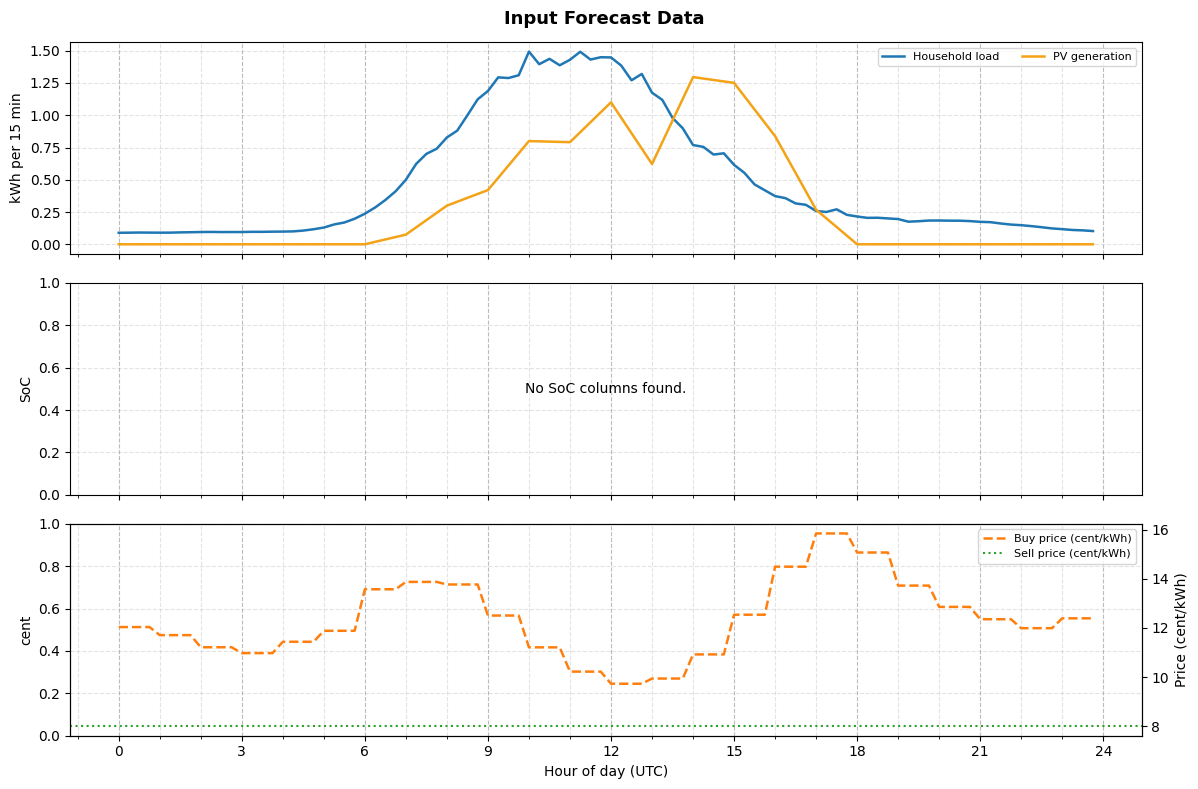

In [59]:
input_forecast_df = pd.read_csv(INPUT_TABLE_PATH)
print(f"Loaded input table from: {INPUT_TABLE_PATH}  ({len(input_forecast_df)} rows)")
input_forecast_df.head()

plot_step_dataframe(
    input_forecast_df,
    params=PARAMS,
    title="Input Forecast Data",
)

## Step 3: Validation And Normalization

Enforces one clean day with 96 UTC intervals and numeric columns ready for dispatch:
- 96 rows, correct timestamp format and spacing.
- Fills missing optional columns with defaults.
- Converts all numeric columns to floats.

In [60]:
def prepare_forecast_input(input_df: pd.DataFrame, params: dict) -> pd.DataFrame:
    missing_required = [col for col in REQUIRED_INPUT_COLUMNS if col not in input_df.columns]
    if missing_required:
        raise ValueError(f"Missing required input columns: {missing_required}")

    df = input_df.copy()
    df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"], utc=True, errors="coerce")
    if df["utc_timestamp"].isna().any():
        bad_rows = df.index[df["utc_timestamp"].isna()].tolist()[:5]
        raise ValueError(f"Invalid utc_timestamp values at rows: {bad_rows}")

    if df["utc_timestamp"].duplicated().any():
        duplicate_count = int(df["utc_timestamp"].duplicated().sum())
        raise ValueError(f"Found {duplicate_count} duplicate utc_timestamp rows.")

    df = df.sort_values("utc_timestamp").reset_index(drop=True)

    numeric_cols = [
        "pv_generation_kwh",
        "energy_price_buy_cent_kwh",
        "household_load_kwh",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        if df[col].isna().any():
            raise ValueError(f"Column '{col}' contains NaN after numeric conversion.")

    if "energy_price_sell_cent_kwh" not in df.columns:
        df["energy_price_sell_cent_kwh"] = params["default_sell_price_cent_kwh"]
    else:
        df["energy_price_sell_cent_kwh"] = pd.to_numeric(df["energy_price_sell_cent_kwh"], errors="coerce")
        df["energy_price_sell_cent_kwh"] = df["energy_price_sell_cent_kwh"].fillna(params["default_sell_price_cent_kwh"])

    if "soc_min_dynamic_kwh" not in df.columns:
        df["soc_min_dynamic_kwh"] = float(params["soc_min_kwh"])
    else:
        df["soc_min_dynamic_kwh"] = pd.to_numeric(df["soc_min_dynamic_kwh"], errors="coerce")
        df["soc_min_dynamic_kwh"] = df["soc_min_dynamic_kwh"].fillna(float(params["soc_min_kwh"]))

    df["soc_min_dynamic_kwh"] = df["soc_min_dynamic_kwh"].clip(
        lower=float(params["soc_min_kwh"]),
        upper=float(params["soc_max_kwh"]),
    )

    for non_negative_col in ["pv_generation_kwh", "household_load_kwh"]:
        if (df[non_negative_col] < 0).any():
            min_value = float(df[non_negative_col].min())
            raise ValueError(f"Column '{non_negative_col}' must be non-negative. Found min={min_value}")

    expected_intervals = int(params["expected_intervals"])
    if len(df) != expected_intervals:
        raise ValueError(f"Expected {expected_intervals} intervals, but got {len(df)}.")

    expected_step = pd.Timedelta(minutes=int(params["interval_minutes"]))
    wrong_step = df["utc_timestamp"].diff().dropna() != expected_step
    if wrong_step.any():
        wrong_positions = wrong_step[wrong_step].index.tolist()[:5]
        raise ValueError(f"Timestamp spacing is not 15-minute UTC at positions: {wrong_positions}")

    return df

Input table validated and normalized.


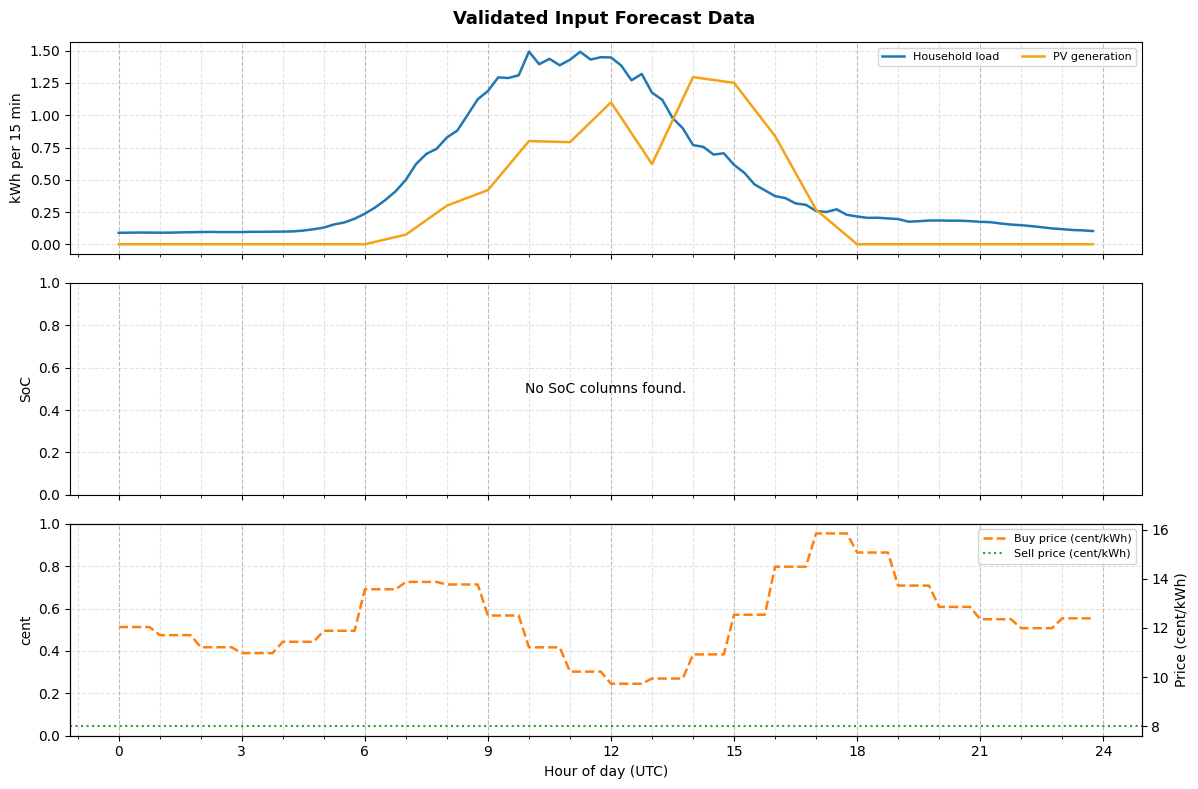

In [61]:
prepared_forecast_df = prepare_forecast_input(input_forecast_df, PARAMS)

if not (PARAMS["soc_min_kwh"] <= INITIAL_SOC_KWH <= PARAMS["soc_max_kwh"]):
    raise ValueError(
        f"INITIAL_SOC_KWH={INITIAL_SOC_KWH} is outside [{PARAMS['soc_min_kwh']}, {PARAMS['soc_max_kwh']}]."
    )

print("Input table validated and normalized.")
prepared_forecast_df.head()

plot_step_dataframe(
    prepared_forecast_df,
    params=PARAMS,
    title="Validated Input Forecast Data",
)

## Step 4: Rule-Based Dispatch

The rule-based dispatcher follows a fixed 6-step sequence in every interval.
The numbering below is aligned 1:1 with the numbered comments in the next code cell.

1. Use PV for household load first.
2. Charge battery from remaining PV (limited by charge power and SoC headroom).
3. Discharge battery to cover remaining load (limited by discharge power and SoC floor).
4. Import grid energy for any uncovered load (limited by grid import constraint).
5. Optionally charge battery from grid when buy price is at or below the configured threshold.
6. Export remaining PV to grid; if export is capped, the remainder is tracked as curtailed PV.

In [62]:
def run_rule_dispatch(forecast_df: pd.DataFrame, params: dict, initial_soc_kwh: float) -> pd.DataFrame:
    dt_hours = params["interval_minutes"] / 60.0
    charge_limit_kwh = params["max_charge_kw"] * dt_hours
    discharge_limit_kwh = params["max_discharge_kw"] * dt_hours
    eta_c = params["charge_efficiency"]
    eta_d = params["discharge_efficiency"]
    soc_min = params["soc_min_kwh"]
    soc_max = params["soc_max_kwh"]
    allow_grid_charging = bool(params.get("allow_grid_charging", False))
    grid_charge_threshold = params.get("grid_charge_price_threshold_cent_kwh")

    soc = float(initial_soc_kwh)
    rows = []

    for row in forecast_df.itertuples(index=False):
        timestamp = row.utc_timestamp
        load_remaining = float(row.household_load_kwh)
        pv_remaining = float(row.pv_generation_kwh)
        buy_price = float(row.energy_price_buy_cent_kwh)
        sell_price = float(row.energy_price_sell_cent_kwh)
        interval_soc_min = float(np.clip(getattr(row, "soc_min_dynamic_kwh", soc_min), soc_min, soc_max))

        # 1) PV serves household load first.
        pv_to_load_kwh = min(load_remaining, pv_remaining)
        load_remaining -= pv_to_load_kwh
        pv_remaining -= pv_to_load_kwh

        # 2) PV surplus charges battery.
        charge_headroom_kwh = max(0.0, (soc_max - soc) / eta_c)
        pv_to_battery_kwh = min(pv_remaining, charge_limit_kwh, charge_headroom_kwh)
        soc += pv_to_battery_kwh * eta_c
        pv_remaining -= pv_to_battery_kwh

        # 3) Battery covers remaining load.
        available_discharge_kwh = max(0.0, (soc - interval_soc_min) * eta_d)
        battery_to_load_kwh = min(load_remaining, discharge_limit_kwh, available_discharge_kwh)
        soc -= battery_to_load_kwh / eta_d
        load_remaining -= battery_to_load_kwh

        # 4) Grid covers uncovered load.
        grid_to_load_kwh = load_remaining

        # 5) Optional grid charging in low-price intervals.
        charge_limit_left_kwh = max(0.0, charge_limit_kwh - pv_to_battery_kwh)
        charge_headroom_kwh = max(0.0, (soc_max - soc) / eta_c)
        should_grid_charge = (
            allow_grid_charging
            and grid_charge_threshold is not None
            and buy_price <= float(grid_charge_threshold)
        )
        grid_to_battery_kwh = min(charge_limit_left_kwh, charge_headroom_kwh) if should_grid_charge else 0.0
        soc += grid_to_battery_kwh * eta_c

        # 6) Export remaining PV to grid.
        export_to_grid_kwh = pv_remaining

        if soc < interval_soc_min - 1e-6 or soc > soc_max + 1e-6:
            raise ValueError(f"SoC out of bounds at {timestamp}: soc={soc:.6f}, bounds=[{interval_soc_min}, {soc_max}]")
        soc = float(np.clip(soc, interval_soc_min, soc_max))

        # Build decision label
        flow_names = ["pv_to_load", "pv_to_battery", "battery_to_load", "grid_to_load", "grid_to_battery", "export_to_grid"]
        flow_vals = [pv_to_load_kwh, pv_to_battery_kwh, battery_to_load_kwh, grid_to_load_kwh, grid_to_battery_kwh, export_to_grid_kwh]
        decision_rule = " | ".join(n for n, v in zip(flow_names, flow_vals) if v > 1e-9) or "idle"

        rows.append({
            "utc_timestamp": timestamp,
            "pv_generation_kwh": row.pv_generation_kwh,
            "household_load_kwh": row.household_load_kwh,
            "energy_price_buy_cent_kwh": buy_price,
            "energy_price_sell_cent_kwh": sell_price,
            "grid_to_load_kwh": grid_to_load_kwh,
            "pv_to_load_kwh": pv_to_load_kwh,
            "pv_to_battery_kwh": pv_to_battery_kwh,
            "battery_to_load_kwh": battery_to_load_kwh,
            "grid_to_battery_kwh": grid_to_battery_kwh,
            "export_to_grid_kwh": export_to_grid_kwh,
            "soc_kwh": soc,
            "soc_min_dynamic_kwh": interval_soc_min,
            "decision_rule": decision_rule,
            "method": "rule_based",
        })

    return _finalize_dispatch_output(pd.DataFrame(rows), params)

method             rule_based
daily_cost_cent       232.854
grid_import_kwh        21.574
grid_export_kwh         0.844
final_soc_kwh           7.397
dtype: object


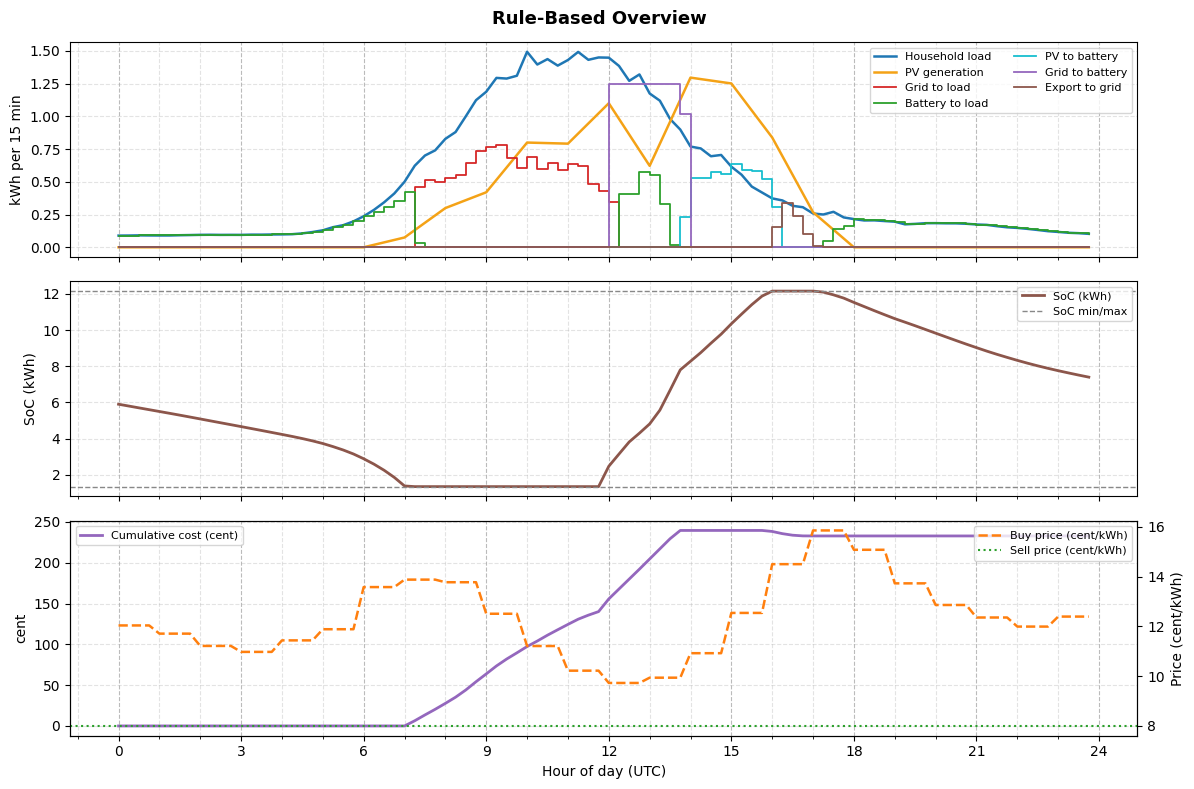

In [63]:
rule_dispatch_df = run_rule_dispatch(prepared_forecast_df, PARAMS, INITIAL_SOC_KWH)

rule_summary = pd.Series(
    {
        "method": "rule_based",
        "daily_cost_cent": round(float(rule_dispatch_df["interval_cost_cent"].sum()), 3),
        "grid_import_kwh": round(float(rule_dispatch_df["total_import_kwh"].sum()), 3),
        "grid_export_kwh": round(float(rule_dispatch_df["total_export_kwh"].sum()), 3),
        "final_soc_kwh": round(float(rule_dispatch_df["soc_kwh"].iloc[-1]), 3),
    }
)

print(rule_summary)

plot_step_dataframe(
    rule_dispatch_df,
    params=PARAMS,
    title="Rule-Based Overview",
)

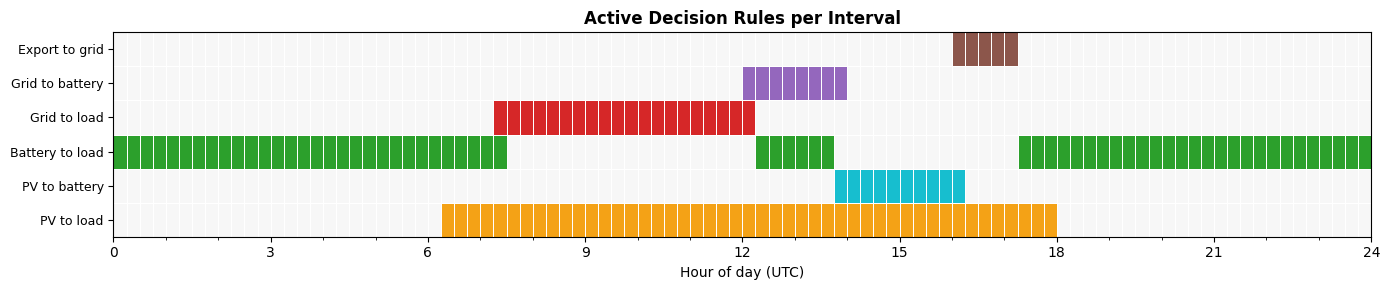

In [64]:
plot_decision_heatmap(rule_dispatch_df)

In [ ]:
timestamps = rule_dispatch_df["utc_timestamp"].dt.strftime("%H:%M UTC")
options = [(ts, i) for i, ts in enumerate(timestamps)]

interact(
    lambda interval: plot_energy_flow_diagram(rule_dispatch_df, interval, PARAMS),
    interval=SelectionSlider(
        options=options, description="Time:",
        style={"description_width": "initial"},
        layout={"width": "600px"},
    ),
);

interactive(children=(SelectionSlider(description='Time:', layout=Layout(width='600px'), options=(('00:00 UTC'…

## Step 5: LP Optimization

Minimizes total daily cost using the same physical constraints as the rule-based approach.
The LP finds optimal trade-offs across all intervals simultaneously (e.g. pre-charging when grid is cheap).

Policy controls:
- `enforce_solar_first_in_lp`: force PV to load before grid/battery use.
- `terminal_soc_value_cent_kwh` / `min_end_soc_kwh`: end-of-day SoC floor.
- `soc_min_dynamic_kwh`: per-interval minimum reserve.

In [66]:
def run_lp_dispatch(forecast_df: pd.DataFrame, params: dict, initial_soc_kwh: float) -> pd.DataFrame:
    n = len(forecast_df)
    dt_hours = params["interval_minutes"] / 60.0
    charge_limit_kwh = params["max_charge_kw"] * dt_hours
    discharge_limit_kwh = params["max_discharge_kw"] * dt_hours

    eta_c = float(params["charge_efficiency"])
    eta_d = float(params["discharge_efficiency"])
    soc_min = float(params["soc_min_kwh"])
    soc_max = float(params["soc_max_kwh"])

    if not (soc_min <= initial_soc_kwh <= soc_max):
        raise ValueError(f"Initial SoC {initial_soc_kwh} must be within [{soc_min}, {soc_max}].")

    load = forecast_df["household_load_kwh"].to_numpy(dtype=float)
    pv = forecast_df["pv_generation_kwh"].to_numpy(dtype=float)
    buy = forecast_df["energy_price_buy_cent_kwh"].to_numpy(dtype=float)
    sell = forecast_df["energy_price_sell_cent_kwh"].to_numpy(dtype=float)

    if "soc_min_dynamic_kwh" in forecast_df.columns:
        soc_min_dynamic = forecast_df["soc_min_dynamic_kwh"].to_numpy(dtype=float)
    else:
        soc_min_dynamic = np.full(shape=n, fill_value=soc_min, dtype=float)
    soc_min_dynamic = np.clip(soc_min_dynamic, soc_min, soc_max)

    cycle_penalty = float(params.get("cycle_penalty_cent_per_kwh", 0.0))
    enforce_solar_first = bool(params.get("enforce_solar_first_in_lp", True))
    terminal_soc_value = float(params.get("terminal_soc_value_cent_kwh", 0.0))
    min_end_soc_kwh = params.get("min_end_soc_kwh")

    # Variable indexing: 7 flow/state variables per interval + 1 initial SoC
    idx_gl  = np.arange(0, n)           # grid to load
    idx_pl  = np.arange(n, 2 * n)       # pv to load
    idx_pb  = np.arange(2 * n, 3 * n)   # pv to battery
    idx_bl  = np.arange(3 * n, 4 * n)   # battery to load
    idx_gb  = np.arange(4 * n, 5 * n)   # grid to battery
    idx_ex  = np.arange(5 * n, 6 * n)   # export to grid
    idx_soc = np.arange(6 * n, 7 * n + 1)
    num_vars = 7 * n + 1

    # 1) Objective: minimize total net cost
    c = np.zeros(num_vars, dtype=float)
    c[idx_gl] = buy
    c[idx_gb] = buy
    c[idx_ex] = -sell
    c[idx_pb] += cycle_penalty
    c[idx_gb] += cycle_penalty
    c[idx_bl] += cycle_penalty
    c[idx_soc[-1]] -= terminal_soc_value

    # 2) Equality constraints
    A_eq_rows = []
    b_eq = []

    for t in range(n):
        # 2.1) Load balance: grid_to_load + pv_to_load + battery_to_load = load
        row = np.zeros(num_vars, dtype=float)
        row[idx_gl[t]] = 1.0
        row[idx_pl[t]] = 1.0
        row[idx_bl[t]] = 1.0
        A_eq_rows.append(row)
        b_eq.append(load[t])

        # 2.2) SoC dynamics
        row = np.zeros(num_vars, dtype=float)
        row[idx_soc[t + 1]] = 1.0
        row[idx_soc[t]] = -1.0
        row[idx_pb[t]] = -eta_c
        row[idx_gb[t]] = -eta_c
        row[idx_bl[t]] = 1.0 / eta_d
        A_eq_rows.append(row)
        b_eq.append(0.0)

    # 3) Inequality constraints
    A_ub_rows = []
    b_ub = []

    for t in range(n):
        # 3.1) PV usage limit
        row = np.zeros(num_vars, dtype=float)
        row[idx_pl[t]] = 1.0
        row[idx_pb[t]] = 1.0
        row[idx_ex[t]] = 1.0
        A_ub_rows.append(row)
        b_ub.append(pv[t])

        # 3.2) Charge power limit
        row = np.zeros(num_vars, dtype=float)
        row[idx_pb[t]] = 1.0
        row[idx_gb[t]] = 1.0
        A_ub_rows.append(row)
        b_ub.append(charge_limit_kwh)

    # 3.3) Optional solar-first: grid_to_load + battery_to_load <= max(0, load - pv)
    if enforce_solar_first:
        for t in range(n):
            row = np.zeros(num_vars, dtype=float)
            row[idx_gl[t]] = 1.0
            row[idx_bl[t]] = 1.0
            A_ub_rows.append(row)
            b_ub.append(max(0.0, load[t] - pv[t]))

    # 4) Variable bounds
    bounds = [(0.0, None)] * num_vars
    for idx in idx_pb:
        bounds[idx] = (0.0, charge_limit_kwh)
    for idx in idx_bl:
        bounds[idx] = (0.0, discharge_limit_kwh)
    for idx in idx_gb:
        bounds[idx] = (0.0, charge_limit_kwh)

    # 4.1) SoC bounds with dynamic reserve floor
    bounds[idx_soc[0]] = (float(initial_soc_kwh), float(initial_soc_kwh))
    for t in range(n):
        bounds[idx_soc[t + 1]] = (float(soc_min_dynamic[t]), soc_max)

    # 4.2) Optional end-of-horizon SoC floor
    if min_end_soc_kwh is not None:
        min_end_soc = float(min_end_soc_kwh)
        if min_end_soc > soc_max:
            raise ValueError(f"min_end_soc_kwh={min_end_soc} exceeds soc_max_kwh={soc_max}.")
        min_end_soc = max(soc_min, min_end_soc)
        current_lb, current_ub = bounds[idx_soc[-1]]
        bounds[idx_soc[-1]] = (max(current_lb, min_end_soc), current_ub)

    # 5) Solve LP
    result = linprog(
        c=c,
        A_ub=np.array(A_ub_rows, dtype=float) if A_ub_rows else None,
        b_ub=np.array(b_ub, dtype=float) if b_ub else None,
        A_eq=np.array(A_eq_rows, dtype=float),
        b_eq=np.array(b_eq, dtype=float),
        bounds=bounds,
        method="highs",
    )

    if not result.success:
        raise RuntimeError(f"LP optimization failed: {result.message}")

    # 6) Extract solution
    x = result.x
    output_df = forecast_df.copy()
    output_df["grid_to_load_kwh"] = x[idx_gl]
    output_df["pv_to_load_kwh"] = x[idx_pl]
    output_df["pv_to_battery_kwh"] = x[idx_pb]
    output_df["battery_to_load_kwh"] = x[idx_bl]
    output_df["grid_to_battery_kwh"] = x[idx_gb]
    output_df["export_to_grid_kwh"] = x[idx_ex]
    output_df["soc_kwh"] = x[idx_soc[1:]]
    output_df["soc_min_dynamic_kwh"] = soc_min_dynamic
    output_df["decision_rule"] = "optimizer_lp"
    output_df["method"] = "optimizer_lp"

    return _finalize_dispatch_output(output_df, params)

In [67]:
def run_dispatch(
    forecast_df: pd.DataFrame,
    params: dict,
    initial_soc_kwh: float,
    use_optimizer: bool = True,
) -> pd.DataFrame:
    if use_optimizer:
        try:
            return run_lp_dispatch(forecast_df, params, initial_soc_kwh)
        except Exception as exc:
            print(f"Optimizer unavailable or failed ({exc}). Falling back to rule-based dispatch.")
    return run_rule_dispatch(forecast_df, params, initial_soc_kwh)


USE_OPTIMIZER = True
dispatch_forecast_df = run_dispatch(
    forecast_df=prepared_forecast_df,
    params=PARAMS,
    initial_soc_kwh=INITIAL_SOC_KWH,
    use_optimizer=USE_OPTIMIZER,
)

comparison_df = pd.DataFrame(
    [
        {
            "method": "rule_based",
            "daily_cost_cent": float(rule_dispatch_df["interval_cost_cent"].sum()),
            "grid_import_kwh": float(rule_dispatch_df["total_import_kwh"].sum()),
            "grid_export_kwh": float(rule_dispatch_df["total_export_kwh"].sum()),
        },
        {
            "method": dispatch_forecast_df["method"].iloc[0],
            "daily_cost_cent": float(dispatch_forecast_df["interval_cost_cent"].sum()),
            "grid_import_kwh": float(dispatch_forecast_df["total_import_kwh"].sum()),
            "grid_export_kwh": float(dispatch_forecast_df["total_export_kwh"].sum()),
        },
    ]
)

comparison_df

,method,daily_cost_cent,grid_import_kwh,grid_export_kwh
0,rule_based,232.854073,21.573800,0.844290
1,optimizer_lp,154.950119,14.416019,0.625036


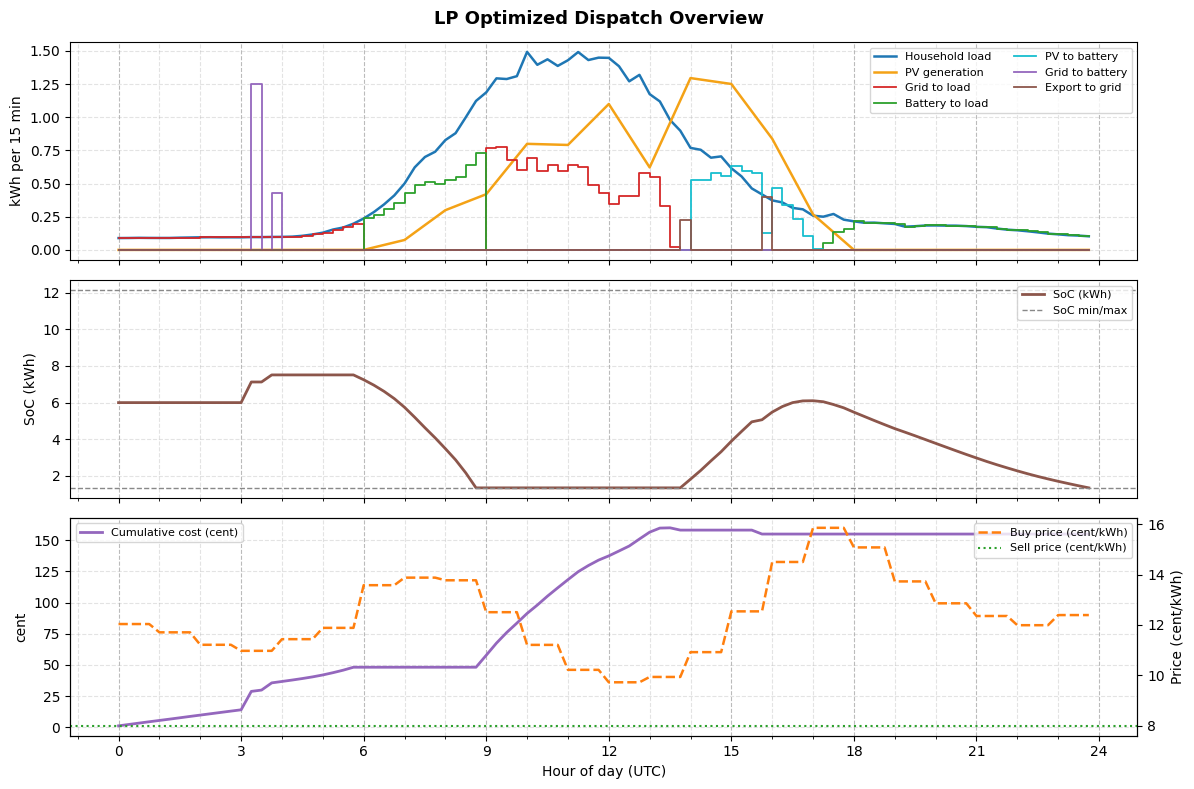

In [68]:
plot_step_dataframe(
    dispatch_forecast_df,
    params=PARAMS,
    title="LP Optimized Dispatch Overview",
)

In [69]:
timestamps = dispatch_forecast_df["utc_timestamp"].dt.strftime("%H:%M UTC")
options = [(ts, i) for i, ts in enumerate(timestamps)]

interact(
    lambda interval: plot_energy_flow_diagram(dispatch_forecast_df, interval, PARAMS),
    interval=SelectionSlider(
        options=options, description="Time:",
        style={"description_width": "initial"},
        layout={"width": "600px"},
    ),
);

interactive(children=(SelectionSlider(description='Time:', layout=Layout(width='600px'), options=(('00:00 UTC'…

## Step 6: Output Forecasting Table

This table is the final schedule with flow directions and SoC.
Save path is created automatically in the `data/` folder.

In [70]:
OUTPUT_COLUMNS = [
    "utc_timestamp",
    "grid_to_load_kwh",
    "pv_to_load_kwh",
    "pv_to_battery_kwh",
    "battery_to_load_kwh",
    "grid_to_battery_kwh",
    "export_to_grid_kwh",
    "soc_kwh",
    "soc_min_dynamic_kwh",
    "energy_price_buy_cent_kwh",
    "energy_price_sell_cent_kwh",
    "interval_cost_cent",
    "cumulative_cost_cent",
    "decision_rule",
    "method",
]

final_dispatch_df = dispatch_forecast_df[OUTPUT_COLUMNS].copy()

output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"battery_dispatch_forecast_{pd.Timestamp.utcnow():%Y%m%d_%H%M%S}.csv"
final_dispatch_df.to_csv(output_path, index=False)

daily_summary = pd.Series(
    {
        "daily_cost_cent": round(float(final_dispatch_df["interval_cost_cent"].sum()), 3),
        "daily_cost_eur": round(float(final_dispatch_df["interval_cost_cent"].sum()) / 100.0, 3),
        "final_soc_kwh": round(float(final_dispatch_df["soc_kwh"].iloc[-1]), 3),
    }
)

print(f"Saved dispatch forecast table to: {output_path}")
daily_summary

Saved dispatch forecast table to: data/battery_dispatch_forecast_20260319_082609.csv


daily_cost_cent    154.95
daily_cost_eur       1.55
final_soc_kwh        1.35
dtype: float64

In [71]:
def run_balance_checks(dispatch_df: pd.DataFrame, tolerance: float = 1e-6) -> pd.Series:
    load_balance_error = (
        dispatch_df["pv_to_load_kwh"]
        + dispatch_df["battery_to_load_kwh"]
        + dispatch_df["grid_to_load_kwh"]
        - dispatch_df["household_load_kwh"]
    ).abs().max()

    pv_balance_error = (
        dispatch_df["pv_to_load_kwh"]
        + dispatch_df["pv_to_battery_kwh"]
        + dispatch_df["export_to_grid_kwh"]
        + dispatch_df.get("curtailed_pv_kwh", 0.0)
        - dispatch_df["pv_generation_kwh"]
    ).abs().max()

    soc_ok = dispatch_df["soc_kwh"].between(
        PARAMS["soc_min_kwh"] - tolerance,
        PARAMS["soc_max_kwh"] + tolerance,
    ).all()

    return pd.Series(
        {
            "max_load_balance_error_kwh": float(load_balance_error),
            "max_pv_balance_error_kwh": float(pv_balance_error),
            "soc_within_bounds": bool(soc_ok),
        }
    )


run_balance_checks(dispatch_forecast_df)

max_load_balance_error_kwh     0.0
max_pv_balance_error_kwh       0.0
soc_within_bounds             True
dtype: object